In [114]:
# para manipulación y análisis de datos estructurados
import pandas as pd

# es el módulo principal de matplotlib, 
# una librería de visualización de gráficos estáticos en 2D.
import matplotlib.pyplot as plt

# Es una magic command de Jupyter Notebook
%matplotlib inline

# es una librería de visualización construida sobre matplotlib, 
# con una sintaxis más simple y gráficos más bonitos
import seaborn as sns


In [115]:
#!pip install pyarrow

<a id='lectura-datos'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">Lectura de Fuente de datos

In [116]:
path = './Origen'

In [117]:
# Identifique el método utilizado para capturar los datos, por ejemplo, ODBC.
articles = pd.read_csv(f'{path}/articles.csv')
customers = pd.read_json(f'{path}/customers.json', orient='split')
transactions = pd.read_parquet(f'{path}/transactions.parquet')

<a id='desc'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">Descripción de los datos

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Articles
Comencemos con los datos de los artículos y echemos un vistazo a las características.

- <b>article_id(int)</b>: Id del artículo de vestir
- <b>product_code(int)</b>
- <b>prod_name(str)</b>: Nombre del producto, incluye información de la categoría
- <b>product_type_no(int)</b>: Código de categoría, puede estar basado en product_group_name
- <b>product_type_name(str)</b>: Nombre de la subcategoría (por ejemplo: pantalones, mallas, pantalones)
- <b>product_group_name(nominal)</b>: Categoría del producto (por ejemplo: ropa interior, parte superior de la prenda)
- <b>graphical_appearance_no(int)</b>
- <b>graphical_appearance_name(nominal)</b>: Describe si la prenda tiene algún diseño o patrón (por ejemplo: liso, rayas)
- <b>colour_group_code(int), colour_group_name(nominal)</b>
- <b>perceived_colour_value_id(int), perceived_colour_value_name(nominal)</b>
- <b>perceived_colour_master_id(int), perceived_colour_master_name(nominal)</b>
- <b>department_no(int), department_name(nominal)</b>
- <b>index_code(str), index_name(nominal)</b>
- <b>index_group_no(int),index_group_name(nominal)</b>
- <b>section_no(int), section_name(nominal)</b>
- <b>garment_group_no(int), garment_group_name(nominal)</b>
- <b>detail_desc(str):</b> Descripción detallada del artículo (por ejemplo: sudadera de algodón orgánico suave con un botón a presión en un hombro)


In [118]:
# ¿Qué dimensiones tiene la base de datos (en números de filas y columnas)?

articles.head(3)
articles.shape

(105542, 25)

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">La mayoría de las funciones están emparejadas como identificación y nombre, los tipos de datos son int y cadena. Las características son nominales, no hay características ordinales en los datos de los artículos.

In [119]:
# ¿Cuál es el formato de los datos?
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

In [120]:
print("El tamaño del archivo de artículos es: ", articles.shape, "\n")
print("El número de entradas nulas en 105542 filas para cada característica es:\n")
articles.isnull().sum()

El tamaño del archivo de artículos es:  (105542, 25) 

El número de entradas nulas en 105542 filas para cada característica es:



article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Este es un conjunto de datos relativamente grande con más de 100.000 filas de datos. Y a casi ninguna de las funciones le faltan valores, excepto Detail_desc.

In [121]:
print("El número de artículos en cada categoría es:\n")
pd.value_counts(articles['index_name'])

El número de artículos en cada categoría es:



C:\Users\wonge\AppData\Local\Temp\ipykernel_15420\236269475.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(articles['index_name'])


index_name
Ladieswear                        26001
Divided                           15149
Menswear                          12553
Children Sizes 92-140             12007
Children Sizes 134-170             9214
Baby Sizes 50-98                   8875
Ladies Accessories                 6961
Lingeries/Tights                   6775
Children Accessories, Swimwear     4615
Sport                              3392
Name: count, dtype: int64

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">LadieswLas categorías ear, Divided, Menswear y Children constituyen la mayor parte de los datos. Visualicemos esto con un diagrama de distribución.

<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">1. Veamos la distribución de productos para cada categoría, que es nombre_grupo_producto.

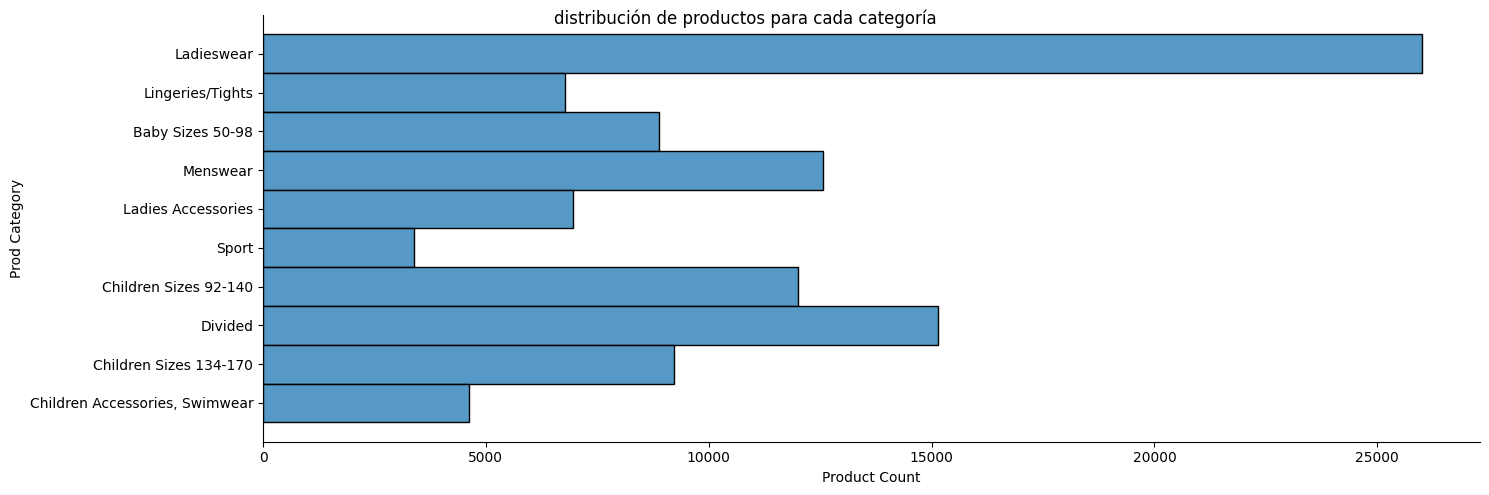

In [122]:
ax = sns.displot(data=articles, y='index_name', aspect=3)
ax.fig.suptitle('distribución de productos para cada categoría')
ax.set_axis_labels('Product Count', 'Prod Category')

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Ahora se puede ver más fácilmente que la categoría dominante es la ropa de mujer, que tiene casi tantos productos como Divided (productos unisex de h&m) y ropa de hombre juntos.

<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">2. Distribución de Categorías (ropa de hombre, ropa de mujer, divididos, etc.) en las categorías de productos (pantalones, camisas, etc.)

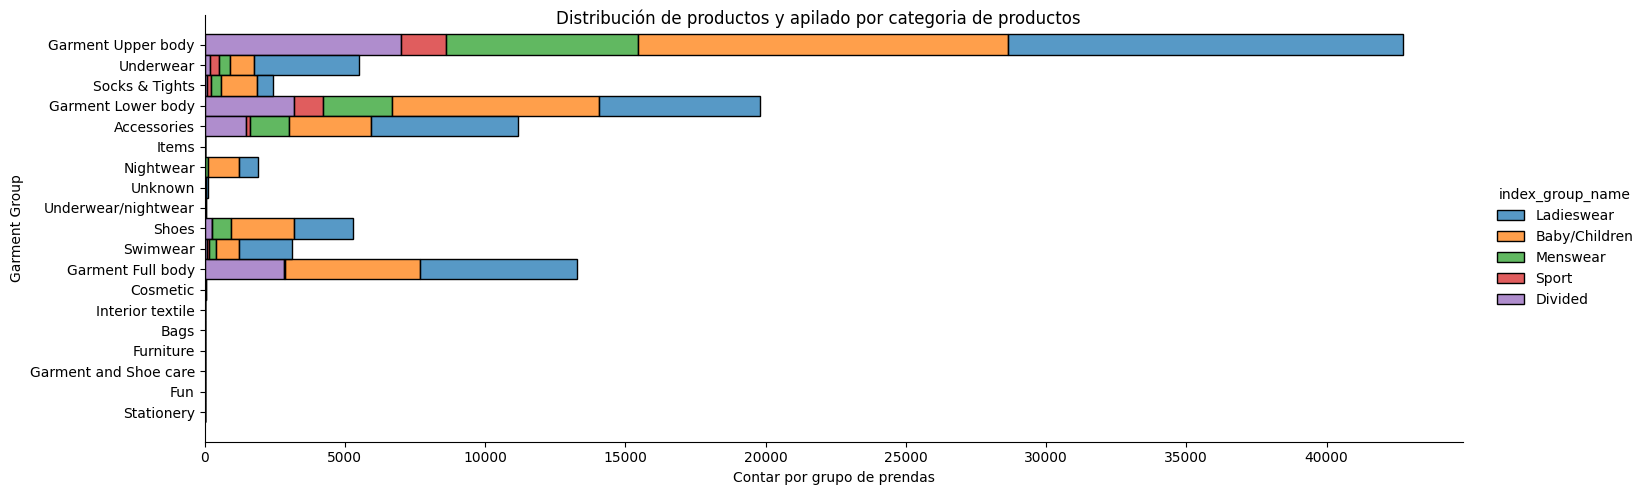

In [13]:
ax = sns.displot(data=articles, y='product_group_name', color='orange', hue='index_group_name', multiple='stack', aspect=3)
ax.fig.suptitle('Distribución de productos y apilado por categoria de productos')
ax.set_axis_labels('Contar por grupo de prendas', 'Garment Group')

<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">3. Número total de productos en cada categoría (index_group_name) y subcategoría (index_name)

In [14]:
#  muestra la cantidad de valores no nulos por grupo
articles.groupby(['index_group_name', 'index_name']).count()['article_id']

index_group_name  index_name                    
Baby/Children     Baby Sizes 50-98                   8875
                  Children Accessories, Swimwear     4615
                  Children Sizes 134-170             9214
                  Children Sizes 92-140             12007
Divided           Divided                           15149
Ladieswear        Ladies Accessories                 6961
                  Ladieswear                        26001
                  Lingeries/Tights                   6775
Menswear          Menswear                          12553
Sport             Sport                              3392
Name: article_id, dtype: int64

In [15]:
grouped = articles.groupby(['index_group_name', 'index_name'])['article_id']
summary = pd.DataFrame({
    'count_not_null': grouped.count(),
    'count_null': grouped.apply(lambda x: x.isna().sum()),
    'total': grouped.size()
})


In [298]:
summary

count_not_null  count_null  \
index_group_name index_name                                                   
Baby/Children    Baby Sizes 50-98                          8875           0   
                 Children Accessories, Swimwear            4615           0   
                 Children Sizes 134-170                    9214           0   
                 Children Sizes 92-140                    12007           0   
Divided          Divided                                  15149           0   
Ladieswear       Ladies Accessories                        6961           0   
                 Ladieswear                               26001           0   
                 Lingeries/Tights                          6775           0   
Menswear         Menswear                                 12553           0   
Sport            Sport                                     3392           0   

                                                 total  
index_group_name index_name                             
Baby/Children    Baby Sizes 50-98                 8875  
                 Children Accessories, Swimwear   4615  
                 Children Sizes 134-170           9214  
                 Children Sizes 92-140           12007  
Divided          Divided                         15149  
Ladieswear       Ladies Accessories               6961  
                 Ladieswear                      26001  
                 Lingeries/Tights                 6775  
Menswear         Menswear                        12553  
Sport            Sport                            3392

<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">4. Recuentos de productos en cada categoría (product_group_name), equivalente al segundo gráfico.

In [16]:
articles.groupby('product_group_name').count()['index_group_name']

product_group_name
Accessories              11158
Bags                        25
Cosmetic                    49
Fun                          2
Furniture                   13
Garment Full body        13292
Garment Lower body       19812
Garment Upper body       42741
Garment and Shoe care        9
Interior textile             3
Items                       17
Nightwear                 1899
Shoes                     5283
Socks & Tights            2442
Stationery                   5
Swimwear                  3127
Underwear                 5490
Underwear/nightwear         54
Unknown                    121
Name: index_group_name, dtype: int64

In [17]:
print("Número de categorías únicas en index_group_name (ladieswear, menswear etc): ",articles['index_group_name'].nunique())
print("Número de colores únicos:", articles['colour_group_name'].nunique())
print("Número de categorías de productos únicas (shoes, accessories, underwear etc): ", articles["product_group_name"].nunique())
print("Número de subcategoría de producto única (boots - sneakers, bras - boxers etc): ", articles['product_type_name'].nunique())

Número de categorías únicas en index_group_name (ladieswear, menswear etc):  5
Número de colores únicos: 50
Número de categorías de productos únicas (shoes, accessories, underwear etc):  19
Número de subcategoría de producto única (boots - sneakers, bras - boxers etc):  131


<a id='customers'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">Customers

In [18]:
print("La forma de los datos de los clientes es:",customers.shape)

La forma de los datos de los clientes es: (1371980, 7)


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Echemos un vistazo a los datos y veamos cuáles son las características.

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">

Los datos de los clientes almacenan la identificación del cliente, su información de membresía de H&M y cierta información personal, metadatos del cliente. Vamos a ver.

- customer_id(int): La identificación de cada cliente en la base de datos.
- FN(categórico): ?
- Activo(categórico): ?
- club_member_status(categórico): ¿Si el cliente utiliza activamente una tarjeta de h&m?
- fashion_news_frequency(categorical): ¿Con qué frecuencia se notifica al cliente sobre nuevos productos, ventas, etc.? (regularmente, mensualmente)
- edad(int): La edad de cada cliente
- postal_code(str): Código postal de cada cliente, pueden estar duplicados

In [19]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355971 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">El recuento de filas que obtuvimos de la forma y la información es 1371980, por lo que podemos ver en los resultados de la información que faltan muchos valores en las columnas FN y Activa, y también algunos valores faltantes en las columnas 3, 4 y 5. Examinemos esos y los valores únicos en esas columnas para comprender mejor lo que representan antes de resumir las características.



<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">5. los valores únicos en la columna 'fashion_news_frequency' y sus distribuciones son:

In [20]:
customers['fashion_news_frequency'].value_counts()

fashion_news_frequency
NONE         877711
Regularly    477416
Monthly         842
None              2
Name: count, dtype: int64

In [21]:
customers['fashion_news_frequency'].value_counts(dropna=False)

fashion_news_frequency
NONE         877711
Regularly    477416
None          16009
Monthly         842
None              2
Name: count, dtype: int64

In [22]:
print("Las entradas en fashion_news_frequency y sus distribuciones son:\n", customers['fashion_news_frequency'].value_counts(dropna=False), "\n")
print("El número de valores nulos en fashion_news_frequency son:", customers['fashion_news_frequency'].isnull().sum(), "\n")
print("Los valores nulos constituyen ", "{:.2f}".format((customers['fashion_news_frequency'].isnull().sum()*100)/len(customers['fashion_news_frequency'])),"%\n")

Las entradas en fashion_news_frequency y sus distribuciones son:
 fashion_news_frequency
NONE         877711
Regularly    477416
None          16009
Monthly         842
None              2
Name: count, dtype: int64 

El número de valores nulos en fashion_news_frequency son: 16009 

Los valores nulos constituyen  1.17 %



<a id='detectar-null'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">6. Detectar null

In [23]:
# Etiqueta
len(customers.query('fashion_news_frequency == "NONE"'))

877711

In [24]:
# Etiqueta
len(customers.query('fashion_news_frequency == "None"'))

2

In [25]:
# Para filtrar si la columna es Null
len(customers.query('fashion_news_frequency.isnull()'))

16009

In [26]:
# Para Detectar si la columna es Null
customers['fashion_news_frequency'].unique()

array(['NONE', 'Regularly', None, 'Monthly', 'None'], dtype=object)

In [27]:
print("{:.2f}".format(((877711+16009+2) *100)/1371980), "% de los clientes no reciben ninguna notificación de ventas o nuevos productos.")

65.14 % de los clientes no reciben ninguna notificación de ventas o nuevos productos.


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Faltan 16.009 puntos de datos en esta columna, pero como el conjunto de datos es bastante grande, eso representa solo el 1,17 % de toda la columna y eso está permitido. Permítanme reemplazar los 2 valores Ninguno por NINGUNO para que sea coherente.

In [28]:
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].replace(['None'], 'NONE')
print("Las entradas en fashion_news_frequency y sus distribuciones son:\n", customers['fashion_news_frequency'].value_counts(dropna=False), "\n")

Las entradas en fashion_news_frequency y sus distribuciones son:
 fashion_news_frequency
NONE         877713
Regularly    477416
None          16009
Monthly         842
Name: count, dtype: int64 



In [29]:
print("Las entradas en FN y sus distribuciones son:\n", customers['FN'].value_counts(dropna=False), "\n")
print("El número de valores nulos en FN son:", customers['FN'].isnull().sum(), "\n")
print("Los valores nulos constituyen ", "{:.2f}".format((customers['FN'].isnull().sum()*100)/len(customers['FN'])),"%")

Las entradas en FN y sus distribuciones son:
 FN
NaN    895050
1.0    476930
Name: count, dtype: int64 

El número de valores nulos en FN son: 895050 

Los valores nulos constituyen  65.24 %


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Más de la mitad de la columna FN es nula y no sabemos qué representa la característica, por lo que parece una buena idea descartarla.

In [30]:
print("Las entradas en Active y sus distribuciones son:\n", customers['Active'].value_counts(dropna=False), "\n")
print("El número de valores nulos en Activo son:", customers['Active'].isnull().sum(), "\n")
print("Los valores nulos constituyen ", "{:.2f}".format((customers['Active'].isnull().sum()*100)/len(customers['Active'])),"%")

Las entradas en Active y sus distribuciones son:
 Active
NaN    907576
1.0    464404
Name: count, dtype: int64 

El número de valores nulos en Activo son: 907576 

Los valores nulos constituyen  66.15 %


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Lo mismo ocurre con la columna Activo, el 66,15% es nulo. Supongo que esta columna representa que el cliente está activo (1.0) si compra en h&m con una frecuencia predeterminada pero aún así tener una columna con 90k valores nulos no es bueno.

<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">7. Veamos la distribución por edades y cuántas personas no registraron su edad para que tal vez podamos imputar los valores nulos para esto.

In [31]:
print("El número de valores nulos en edad son:", customers['age'].isnull().sum(), "\n")
print("Los valores nulos constituyen ", "{:.2f}".format((customers['age'].isnull().sum()*100)/len(customers['age'])),"%")

El número de valores nulos en edad son: 15861 

Los valores nulos constituyen  1.16 %


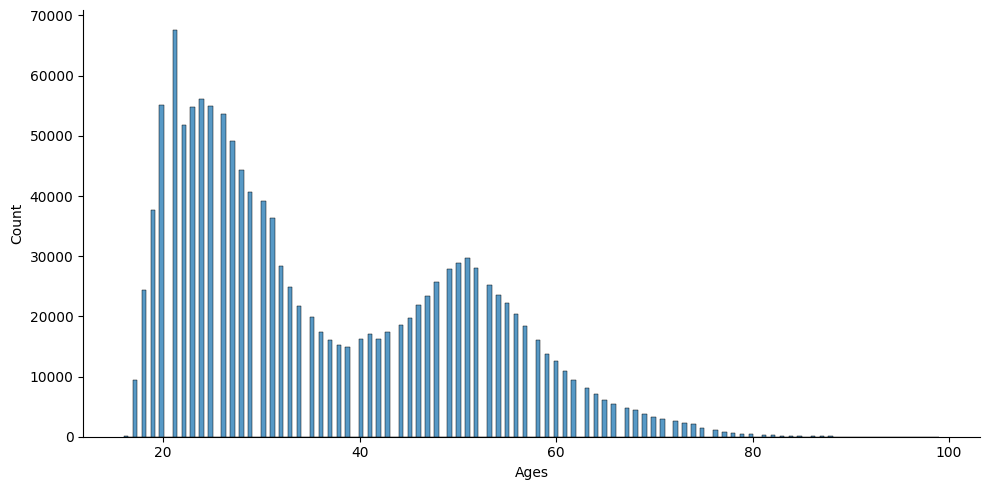

In [32]:
age_plot = sns.displot(data=customers, x='age', aspect=2)
age_plot.set_axis_labels('Ages', 'Count')
plt.show()

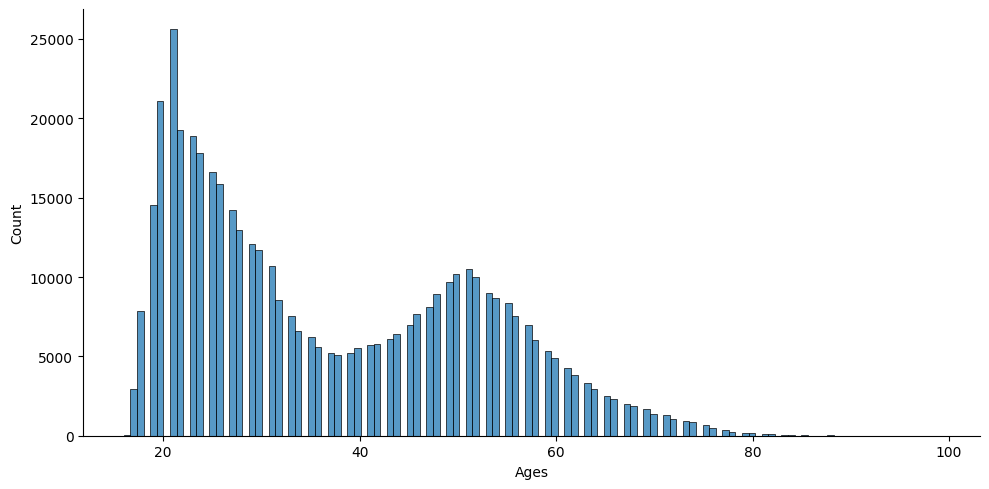

In [33]:
age_plot = sns.displot(data=customers.query('Active == 1'), x='age', aspect=2)
age_plot.set_axis_labels('Ages', 'Count')
plt.show()

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">La mayoría de los clientes tienen entre 20 y 30 años, una cantidad significativa tiene entre 45 y 55 años. Echemos un vistazo más de cerca a los datos de edad, veamos algunas estadísticas descriptivas y examinemos los valores atípicos. Podemos reemplazar los valores atípicos con el valor medio o mediano de la columna de edad, dependiendo de cuál represente mejor la edad. Pero también podemos eliminarlos si queremos, ya que el número de valores atípicos es realmente bajo, probablemente <1%.

In [34]:
print("Range Of Ages    Count\n")
customers['age'].value_counts(bins=10, ascending=False)

Range Of Ages    Count



(15.916, 24.3]    357169
(24.3, 32.6]      346715
(49.2, 57.5]      196469
(40.9, 49.2]      187960
(32.6, 40.9]      146283
(57.5, 65.8]       83956
(65.8, 74.1]       31583
(74.1, 82.4]        5388
(82.4, 90.7]         519
(90.7, 99.0]          77
Name: count, dtype: int64

In [35]:
print("{:.2f}".format(((357169+346715)*100)/1356119), "% de los clientes tienen entre 15,9 y 32,6 años")

51.90 % de los clientes tienen entre 15,9 y 32,6 años


<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">8. Realizando un pareto

C:\Users\wonge\AppData\Local\Temp\ipykernel_8908\818521612.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts_sorted.index, y=age_counts_sorted.values, palette=['red' if i < cutoff_index else 'green' for i in range(len(age_counts_sorted))])


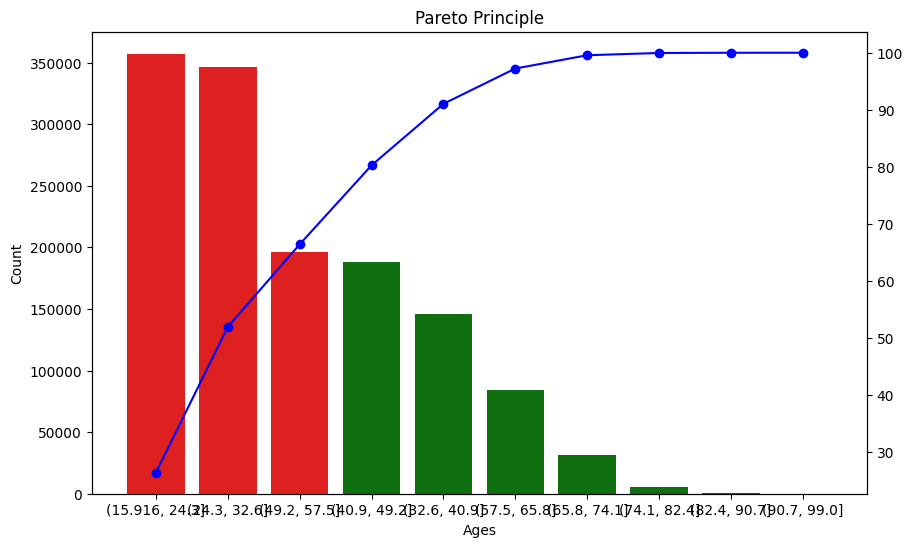

Punto de corte para el 80% de los resultados: (40.9, 49.2]


In [36]:
# Calcular los recuentos de las edades en 10 bins
age_counts = customers['age'].value_counts(bins=10, ascending=False)

# Ordenar los recuentos de mayor a menor
age_counts_sorted = age_counts.sort_values(ascending=False)

# Calcular el porcentaje acumulado
cumulative_percentage = age_counts_sorted.cumsum() / age_counts_sorted.sum() * 100

# Encontrar el punto de corte para el 80%
cutoff_index = (cumulative_percentage <= 80).sum()

# Crear el gráfico de barras con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=age_counts_sorted.index, y=age_counts_sorted.values, palette=['red' if i < cutoff_index else 'green' for i in range(len(age_counts_sorted))])

# Establecer etiquetas de los ejes
plt.xlabel('Ages')
plt.ylabel('Count')
plt.title('Pareto Principle')

# Ajustar la línea para el punto de corte del 80%
plt.twinx()
plt.plot(range(len(age_counts_sorted)), cumulative_percentage, color='blue', marker='o', linestyle='-')

# Mostrar el gráfico
plt.show()

print("Punto de corte para el 80% de los resultados:", age_counts_sorted.index[cutoff_index])

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Los resultados de la función de descripción para la columna de edad son un poco feos, así que hagamos algunos de ellos manualmente.

In [37]:
print("Valor de edad media:", customers['age'].mean())
print("El valor de la edad mediana es:", customers['age'].median())
print("Desviación estándar de la edad:", customers['age'].std())

Valor de edad media: 36.386964565794
El valor de la edad mediana es: 32.0
Desviación estándar de la edad: 14.313627981628066


<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">9. Ahora tracemos un diagrama de caja para la edad.

<Axes: xlabel='age', ylabel='Count'>

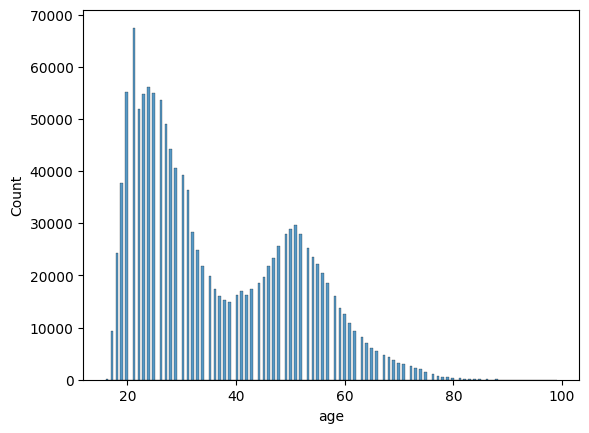

In [38]:
sns.histplot(data=customers, x='age')

<Axes: xlabel='age'>

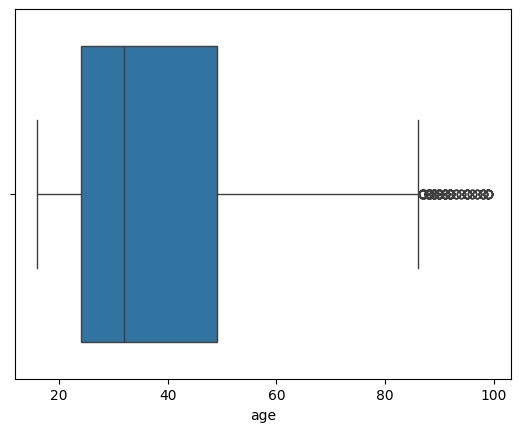

In [323]:
sns.boxplot(data=customers, x='age')

In [39]:
age_clean = customers['age'].dropna()  # elimina los NaN

Q1 = age_clean.quantile(0.25)
Q2 = age_clean.quantile(0.50)  # mediana
Q3 = age_clean.quantile(0.75)
IQR = Q3 - Q1

# Límites para los bigotes (whiskers)
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

# Outliers
outliers = age_clean[(age_clean < lower_whisker) | (age_clean > upper_whisker)]

In [40]:
summary = {
    'Q1': Q1,
    'Median': Q2,
    'Q3': Q3,
    'IQR': IQR,
    'Lower Whisker': lower_whisker,
    'Upper Whisker': upper_whisker,
    'Outlier count': len(outliers)
}
summary

{'Q1': np.float64(24.0),
 'Median': np.float64(32.0),
 'Q3': np.float64(49.0),
 'IQR': np.float64(25.0),
 'Lower Whisker': np.float64(-13.5),
 'Upper Whisker': np.float64(86.5),
 'Outlier count': 214}

In [41]:
# Filtrar la columna 'age' sin nulos
ages = customers['age'].dropna()

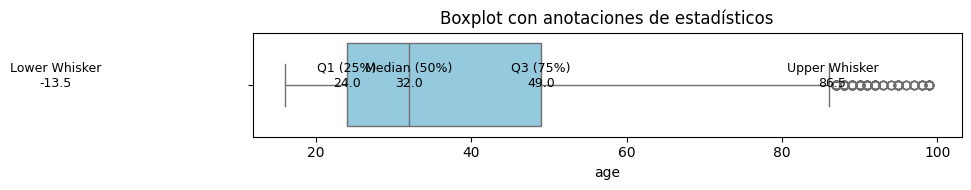

In [42]:
plt.figure(figsize=(10, 2))
ax = sns.boxplot(x=ages, color="skyblue")

# Anotar valores
for val, label in [
    (lower_whisker, 'Lower Whisker'),
    (Q1, 'Q1 (25%)'),
    (Q2, 'Median (50%)'),
    (Q3, 'Q3 (75%)'),
    (upper_whisker, 'Upper Whisker')
]:
    ax.text(val, 0.05, f'{label}\n{val:.1f}', ha='center', va='bottom', color='black', fontsize=9)

plt.title('Boxplot con anotaciones de estadísticos')
plt.tight_layout()
plt.show()


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Hay valores atípicos desde los 85 hasta los 100 años y probablemente podamos eliminarlos. Comprobemos cuántos hay primero.

In [43]:
customers[customers['age'] > 85].count()

customer_id               264
FN                         75
Active                     67
club_member_status        261
fashion_news_frequency    260
age                       264
postal_code               264
dtype: int64

In [44]:
customers['customer_id'].nunique()

1371980

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Dado que cada customer_id es único en el conjunto de datos y el filtro de edad arrojó 264 customer_id, podemos decir que hay 264 filas con edad > 85, por lo que hay 264 valores atípicos, lo que representa el 0,02 % de todo el conjunto de datos.

In [45]:
customers.drop(customers[customers['age'] > 85].index, inplace=True)

In [46]:
customers = customers.query('age <= 85')
customers.query('age <= 85')

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...
...,...,...,...,...,...,...,...
1371975,ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e474...,NaN,NaN,ACTIVE,NONE,24.0,7aa399f7e669990daba2d92c577b52237380662f36480b...
1371976,ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab5...,NaN,NaN,ACTIVE,NONE,21.0,3f47f1279beb72215f4de557d950e0bfa73789d24acb5e...
1371977,ffffcf35913a0bee60e8741cb2b4e78b8a98ee5ff2e6a1...,1.0,1.0,ACTIVE,Regularly,21.0,4563fc79215672cd6a863f2b4bf56b8f898f2d96ed590e...
1371978,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,1.0,ACTIVE,Regularly,18.0,8892c18e9bc3dca6aa4000cb8094fc4b51ee8db2ed14d7...


In [47]:
customers[customers['age'] > 85]

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code


<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">10. Correlación en base a la agrupación por edad

In [48]:
customers.groupby('age', as_index=False).count().corr()*100

,age,customer_id,FN,Active,club_member_status,fashion_news_frequency,postal_code
age,100.000000,-78.627637,-76.225023,-76.238178,-78.613240,-78.615559,-78.627637
customer_id,-78.627637,100.000000,98.702686,98.775710,99.999956,99.999794,100.000000
FN,-76.225023,98.702686,100.000000,99.995326,98.699227,98.710776,98.702686
Active,-76.238178,98.775710,99.995326,100.000000,98.772240,98.782777,98.775710
club_member_status,-78.613240,99.999956,98.699227,98.772240,100.000000,99.999783,99.999956
fashion_news_frequency,-78.615559,99.999794,98.710776,98.782777,99.999783,100.000000,99.999794
postal_code,-78.627637,100.000000,98.702686,98.775710,99.999956,99.999794,100.000000


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">

- correlación = 1; En análisis de datos o modelos, una puede ser redundante respecto a la otra
- ❗Pero cuidado: el postal_code suele ser un identificador categórico (no ordinal). 
- Si lo has convertido a número, esta correlación puede ser espuria o artificial.

- No tiene sentido usar correlación de Pearson con códigos que son simplemente etiquetas.

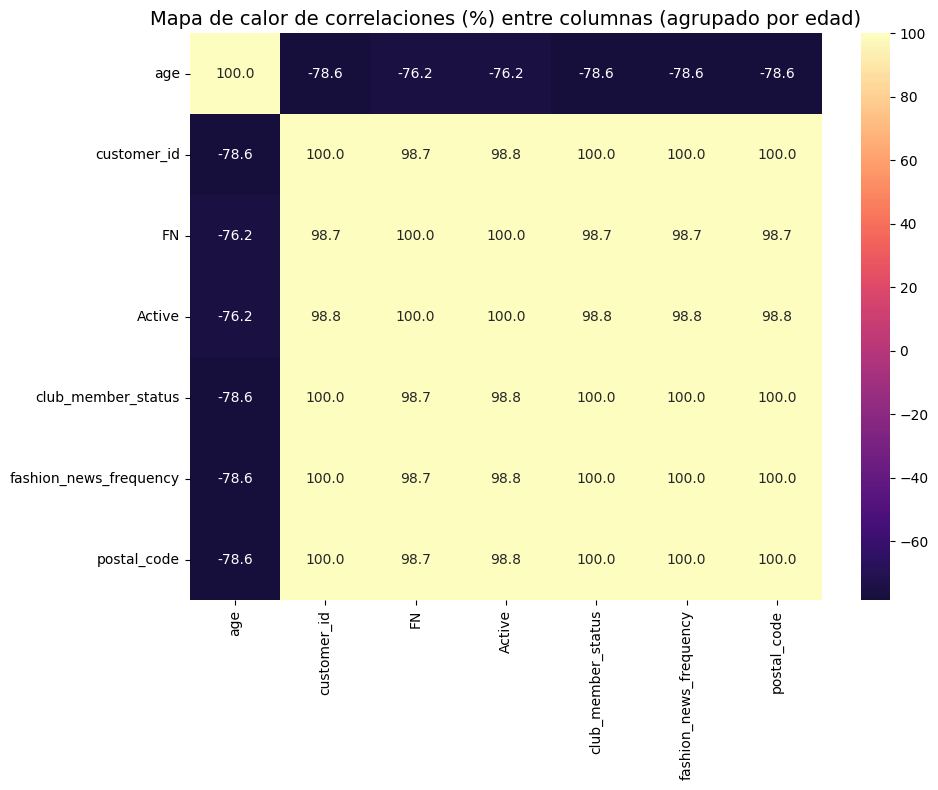

In [49]:
# 1. Agrupar por edad y contar cuántos valores hay por edad en cada columna
corr_matrix = customers.groupby('age', as_index=False).count().corr() * 100

# 2. Crear el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='magma', center=0)

# 3. Título y ajustes
plt.title("Mapa de calor de correlaciones (%) entre columnas (agrupado por edad)", fontsize=14)
plt.tight_layout()
plt.show()


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">

| Paleta       | Descripción                                  |
| ------------ | -------------------------------------------- |
| `"coolwarm"` | Azul a rojo (buena para valores centrados)   |
| `"viridis"`  | Colores suaves, ideal para percepción humana |
| `"magma"`    | Tonos oscuros a claros (negro a amarillo)    |
| `"YlGnBu"`   | Amarillo → Verde → Azul                      |
| `"RdBu"`     | Rojo → Blanco → Azul                         |
| `"Blues"`    | Diferentes tonos de azul                     |
| `"PuBuGn"`   | Púrpura → Azul → Verde                       |


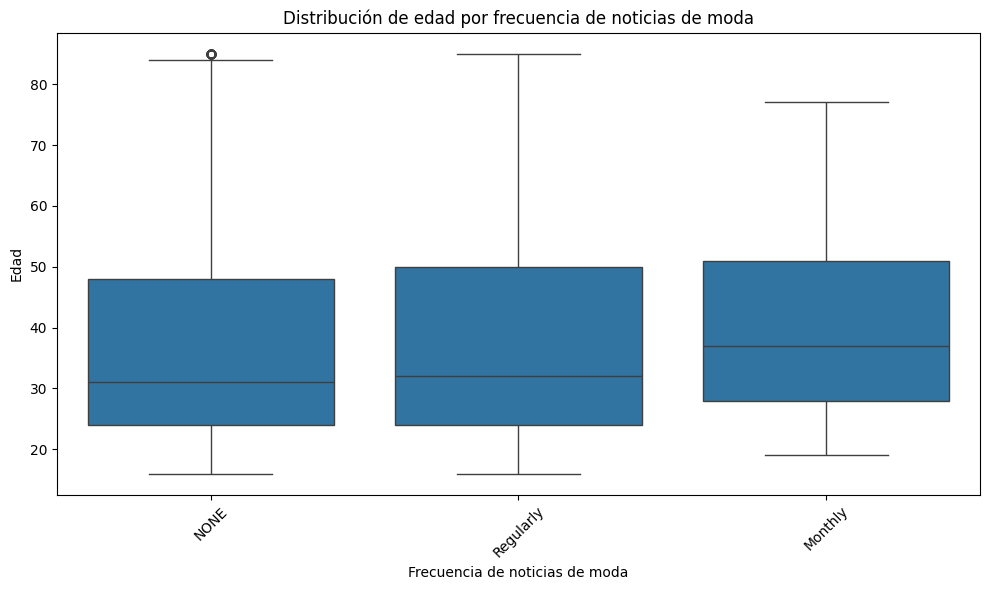

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customers, x='fashion_news_frequency', y='age')
plt.title('Distribución de edad por frecuencia de noticias de moda')
plt.xlabel('Frecuencia de noticias de moda')
plt.ylabel('Edad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">11. Correlación basado en pearson por fashion_news_frequency, age (se realiza conversion a numérico - fashion_news_frequency)

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Un encoder es una técnica o herramienta que convierte valores categóricos (por ejemplo: “rojo”, “verde”, “azul”) en valores numéricos para que puedan ser utilizados por modelos de machine learning.


In [51]:
from sklearn.preprocessing import LabelEncoder

df_encoded = customers.dropna(subset=['fashion_news_frequency', 'age']).copy()
le = LabelEncoder()
df_encoded['fashion_code'] = le.fit_transform(df_encoded['fashion_news_frequency'])

# Correlación de Pearson
corr = df_encoded[['fashion_code', 'age']].corr().iloc[0,1]
print(f"Correlación Pearson entre 'fashion' codificada y 'age': {corr*100:.4f}")

Correlación Pearson entre 'fashion' codificada y 'age': 3.3897



<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">

| Encoder                | ¿Qué hace?                                                                                 | ¿Cuándo usarlo?                                                              |
| ---------------------- | ------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------- |
| **Label Encoding**     | Asigna un número entero a cada categoría. Ej: “rojo” → 0, “verde” → 1, “azul” → 2          | Cuando las categorías **tienen un orden natural** (ordinales).               |
| **One-Hot Encoding**   | Crea una columna por cada categoría. Ej: “rojo” → \[1,0,0], “verde” → \[0,1,0], etc.       | Cuando las categorías **no tienen orden** (nominales).                       |
| **Ordinal Encoding**   | Similar al Label Encoding, pero especificando **un orden explícito** de las categorías.    | Para datos con **jerarquía lógica** (ej. bajo, medio, alto).                 |
| **Binary Encoding**    | Convierte las categorías en binario y luego separa los bits en columnas.                   | Para muchas categorías; **más eficiente** que One-Hot con alta cardinalidad. |
| **Frequency Encoding** | Reemplaza cada categoría por su **frecuencia** en el dataset.                              | Cuando el número de ocurrencias **importa**.                                 |
| **Target Encoding**    | Sustituye cada categoría por el **promedio del target** (por ejemplo, la media de ventas). | En tareas de **modelos supervisados**, pero puede causar overfitting.        |
| **Hash Encoding**      | Usa una función hash para asignar categorías a columnas de forma fija y eficiente.         | En datasets con **miles de categorías** (alta cardinalidad).                 |


<a id='transactions'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">Transactions

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">

31788324 filas y 5 características en los datos de transacciones.

Funciones de transacciones:
- <b>t_dat (objeto):</b> Fecha de las transacciones. ¿Se puede convertir a fecha y hora?
- <b>id_cliente</b>
- <b>article_id (int):</b> Id de la ropa comprada
- <b>precio(int)</b>: Precio de la prenda de vestir
- <b>sales_channel_id(categorical):</b>Categoría de canal de ventas (tienda, online): los valores son 1 y 2, no sabemos cuál es cuál.

In [123]:
#Formato para que los resultados de la descripción sean más legibles
#, afecta todo lo que aparece a continuación
pd.set_option('display.float_format', '{:.6f}'.format) 
transactions.describe()

,article_id,price,sales_channel_id
count,31788324.000000,31788324.000000,31788324.000000
mean,696227219.133793,0.027829,1.704028
std,133448003.487313,0.019181,0.456479
min,108775015.000000,0.000017,1.000000
25%,632803008.000000,0.015814,1.000000
50%,714582003.000000,0.025407,2.000000
75%,786524001.000000,0.033881,2.000000
max,956217002.000000,0.591525,2.000000


In [124]:
transactions.drop_duplicates().describe()

,article_id,price,sales_channel_id
count,28813419.000000,28813419.000000,28813419.000000
mean,697146215.871254,0.027729,1.683251
std,132153811.850356,0.019101,0.465209
min,108775015.000000,0.000017,1.000000
25%,633152012.000000,0.015678,1.000000
50%,714790001.000000,0.025407,2.000000
75%,787153001.000000,0.033881,2.000000
max,956217002.000000,0.591525,2.000000


<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:13px">12. VENTAJAS Y DESVENTAJAS DE MANTENER DUPLICADOS 


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">


| **Aspecto**                              | **Ventajas de mantener duplicados**                                                                       | **Desventajas de mantener duplicados**                                                                      |
| ---------------------------------------- | --------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------- |
| **1. Representación de la realidad**     | Si los duplicados reflejan eventos reales (por ejemplo, transacciones repetidas), aportan validez.        | Si los duplicados no son reales, distorsionan el comportamiento real del sistema.                           |
| **2. Tamaño del dataset**                | En datasets muy pequeños, mantener duplicados puede evitar que el modelo tenga escasez de datos.          | Aumenta innecesariamente el tamaño del dataset, lo que implica mayor consumo de memoria y cómputo.          |
| **3. Aprendizaje de patrones**           | En casos raros, repetir un patrón relevante podría reforzarlo en modelos que lo necesitan.                | El modelo puede memorizar ejemplos específicos en vez de generalizar (overfitting).                         |
| **4. Distribución de clases**            | Puede reflejar una distribución natural si ciertos casos se repiten legítimamente.                        | Puede introducir **desbalance artificial**, afectando negativamente a la predicción de clases minoritarias. |
| **5. Impacto en métricas de evaluación** | A veces mejora artificialmente las métricas (accuracy, F1) en validación si hay fuga de datos.            | Las métricas pueden ser engañosas por la redundancia. Aumenta el riesgo de **data leakage**.                |
| **6. Modelos sensibles a pesos**         | Algunos modelos (p.ej., Naive Bayes, regresión logística con pesos) pueden beneficiarse de la frecuencia. | La frecuencia de duplicados puede sesgar el modelo y hacer que dependa de datos irrelevantes.               |
| **7. Limpieza de datos**                 | No es necesario hacer preprocesamiento si los duplicados son intencionales.                               | Obliga a hacer un análisis más profundo para identificar si hay errores o datos redundantes.                |


In [125]:
%%time
transactions.groupby(['t_dat', 'customer_id', 'article_id', 'sales_channel_id']).agg({
    'price': 'sum'
}).reset_index().to_parquet('transactions_agg')


CPU times: total: 45.4 s
Wall time: 46.3 s


In [126]:
transactions = pd.read_parquet('transactions_agg')

In [127]:
transactions.describe()

,article_id,sales_channel_id,price
count,28583889.000000,28583889.000000,28583889.000000
mean,697398489.243995,1.682593,0.030949
std,131727610.245217,0.465467,0.025560
min,108775015.000000,1.000000,0.000017
25%,633377003.000000,1.000000,0.016932
50%,714790003.000000,2.000000,0.025407
75%,787216001.000000,2.000000,0.035102
max,956217002.000000,2.000000,5.666441


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">se multiplica por 50000 dado que los datos son anonimizados

In [128]:
transactions.price = transactions.price*50000

### 13. top 10 de los clientes.

In [129]:
transactions_for_each_cust = transactions.groupby('customer_id').count()

In [130]:
transactions_for_each_cust.sort_values(by='price', ascending=False)['price'][:10]

customer_id
be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee985513d9e8e53c6d91b    1636
b4db5e5259234574edfff958e170fe3a5e13b6f146752ca066abca3c156acc71    1310
a65f77281a528bf5c1e9f270141d601d116e1df33bf9df512f495ee06647a9cc    1302
49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05b50a4cd88e34d0748f    1225
cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed6012e7e5bea016b4d6    1209
55d15396193dfd45836af3a6269a079efea339e875eff42cc0c228b002548a9d    1112
d80ed4ababfa96812e22b911629e6bcbf5093769051ea447e2b696ac98a3dae9     981
689f4eda82fdf3d9bfe8e524bbd0d931c4d7690f2234d3e48779f924aaf4103d     977
6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2e57161f0ef810a4b55     973
3493c55a7fe252c84a9a03db338f5be7afbce1edbca12f3a908fac9b983692f2     971
Name: price, dtype: int64

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">transacciones para el cliente Top 1

In [131]:
num_one_cust_transactions = pd.DataFrame(transactions[transactions['customer_id'] == 'be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee985513d9e8e53c6d91b'])

In [132]:
print("Número total de transacciones para el cliente número uno:", num_one_cust_transactions.shape[0])
print("De esas transacciones, las ventas realizadas utilizando sales_channel_id:\n", num_one_cust_transactions.sales_channel_id.value_counts())

Número total de transacciones para el cliente número uno: 1636
De esas transacciones, las ventas realizadas utilizando sales_channel_id:
 sales_channel_id
2    1282
1     354
Name: count, dtype: int64


In [133]:
def calcular_porcentaje_por_canal(transactions, channel_id):
    channel_count = transactions[transactions['sales_channel_id'] == channel_id]['sales_channel_id'].count()
    total_count = transactions['sales_channel_id'].count()
    porcentaje = (channel_count * 100) / total_count
    return porcentaje

In [134]:
porcentaje_canal_1 = calcular_porcentaje_por_canal(transactions, 1)
porcentaje_canal_2 = calcular_porcentaje_por_canal(transactions, 2)

print("Porcentaje de transacciones del canal de ventas 1:", "{:.1f}".format(porcentaje_canal_1))
print("Porcentaje de transacciones del canal de ventas 2:", "{:.1f}".format(porcentaje_canal_2))

Porcentaje de transacciones del canal de ventas 1: 31.7
Porcentaje de transacciones del canal de ventas 2: 68.3


In [135]:
print("Porcentaje de transacciones del canal de ventas 1:", "{:.1f}".format((transactions[transactions['sales_channel_id'] == 1]['sales_channel_id'].count()*100)/transactions['sales_channel_id'].count()))
print(f"Porcentaje de transacciones del canal de ventas 2:", "{:.1f}".format((transactions[transactions['sales_channel_id'] == 2]['sales_channel_id'].count()*100)/transactions['sales_channel_id'].count()))

Porcentaje de transacciones del canal de ventas 1: 31.7
Porcentaje de transacciones del canal de ventas 2: 68.3


### 14.Union de conjuntos de datos

<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">Podemos fusionar los marcos de datos de artículos y transacciones para ver qué tan popular es cada categoría/subcategoría. Obtengamos un subconjunto de las características de los datos de los artículos y unámoslas en la columna Article_id común.

In [136]:
%%time
transactions_merged = transactions\
    .merge(customers[['customer_id', 'Active', 'fashion_news_frequency', 'age']], on='customer_id', how='left')\
    .merge(articles[['article_id', 'product_type_name', 'product_group_name', 'index_group_name', 'index_name']], on="article_id", how="left")

CPU times: total: 25.3 s
Wall time: 26 s


In [137]:
transactions_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28583889 entries, 0 to 28583888
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   t_dat                   object 
 1   customer_id             object 
 2   article_id              int64  
 3   sales_channel_id        int64  
 4   price                   float64
 5   Active                  float64
 6   fashion_news_frequency  object 
 7   age                     float64
 8   product_type_name       object 
 9   product_group_name      object 
 10  index_group_name        object 
 11  index_name              object 
dtypes: float64(3), int64(2), object(7)
memory usage: 2.6+ GB


### 15.Artículos más populares ahora.

In [138]:
transactions_merged['article_id'].value_counts()

article_id
706016001    42155
706016002    30548
372860001    29180
610776002    24980
759871002    23589
             ...  
874852001        1
695682007        1
760195004        1
895563001        1
913290001        1
Name: count, Length: 104547, dtype: int64

In [139]:
articles[articles['article_id'] == 706016001]  

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
53892,706016001,706016,Jade HW Skinny Denim TRS,272,Trousers,Garment Lower body,1010016,Solid,9,Black,...,Trousers,D,Divided,2,Divided,53,Divided Collection,1009,Trousers,High-waisted jeans in washed superstretch deni...


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">La prenda que más se ha vendido es un sencillo pantalón negro de la sección dividida. Los otros 4 son pantalones, tops y calcetines.

<Axes: xlabel='price'>

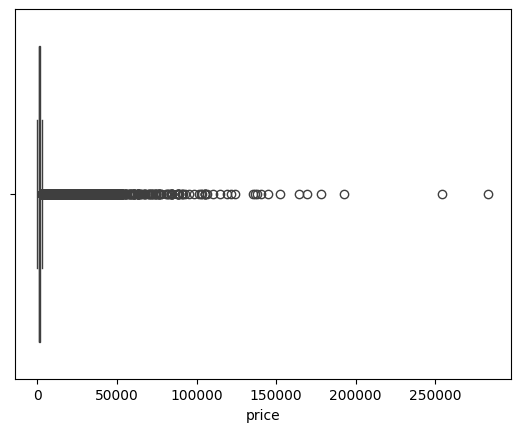

In [69]:
sns.boxplot(data=transactions_merged, x='price')

In [140]:
# Eliminar filas con nulos
subset = transactions_merged[['age', 'price']].dropna()

# Correlación de Pearson
corr = subset.corr().loc['age', 'price']
print(f'Correlación Pearson entre edad y precio: {corr:.4f}')

Correlación Pearson entre edad y precio: 0.0463


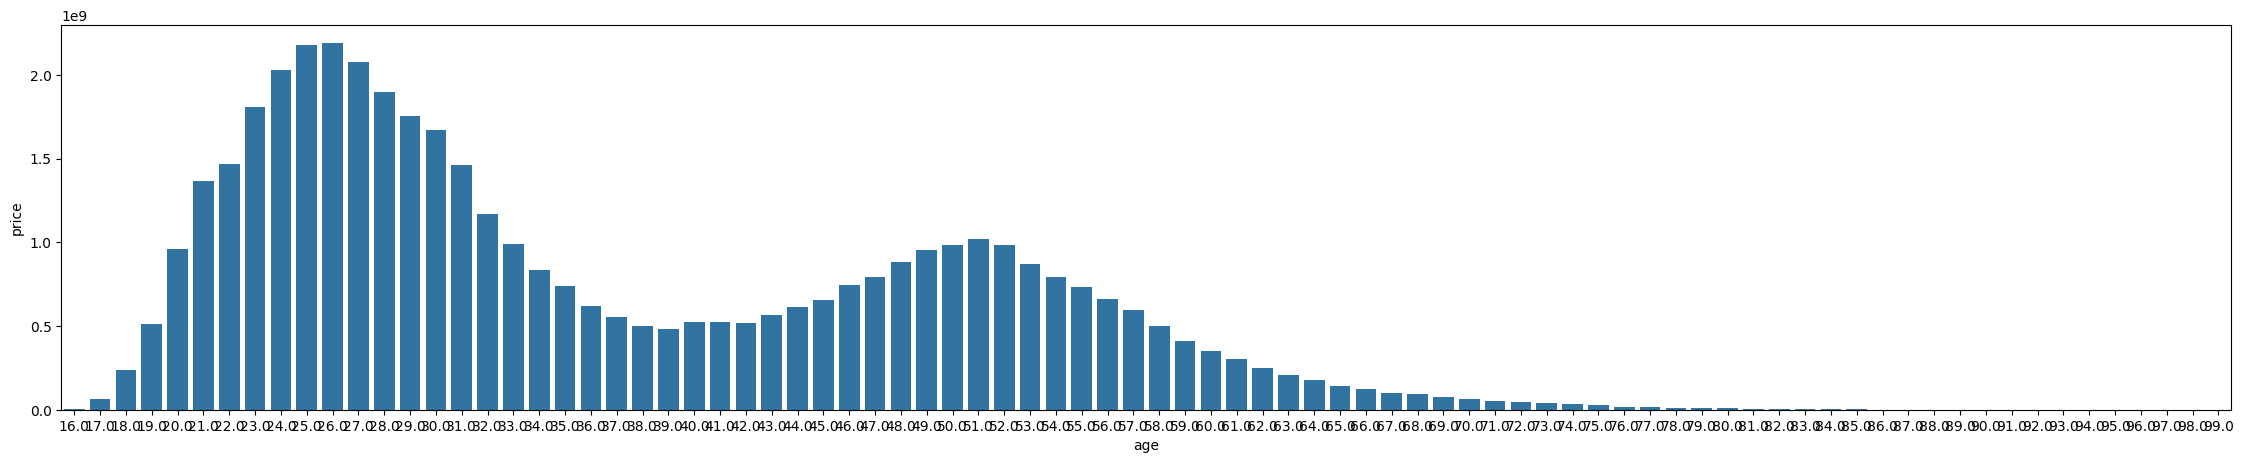

In [141]:
price_age = transactions_merged.groupby('age', as_index = False)['price'].sum()
plt.figure(figsize=(28, 5))
sns.barplot(data=price_age, x='age', y='price')
plt.show()

C:\Users\wonge\AppData\Local\Temp\ipykernel_15420\4188372273.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_price_age = df_price_age.groupby('age_group', as_index=False)['price'].sum()
C:\Users\wonge\AppData\Local\Temp\ipykernel_15420\4188372273.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_price_age, x='age_group', y='price', palette='Blues_d')


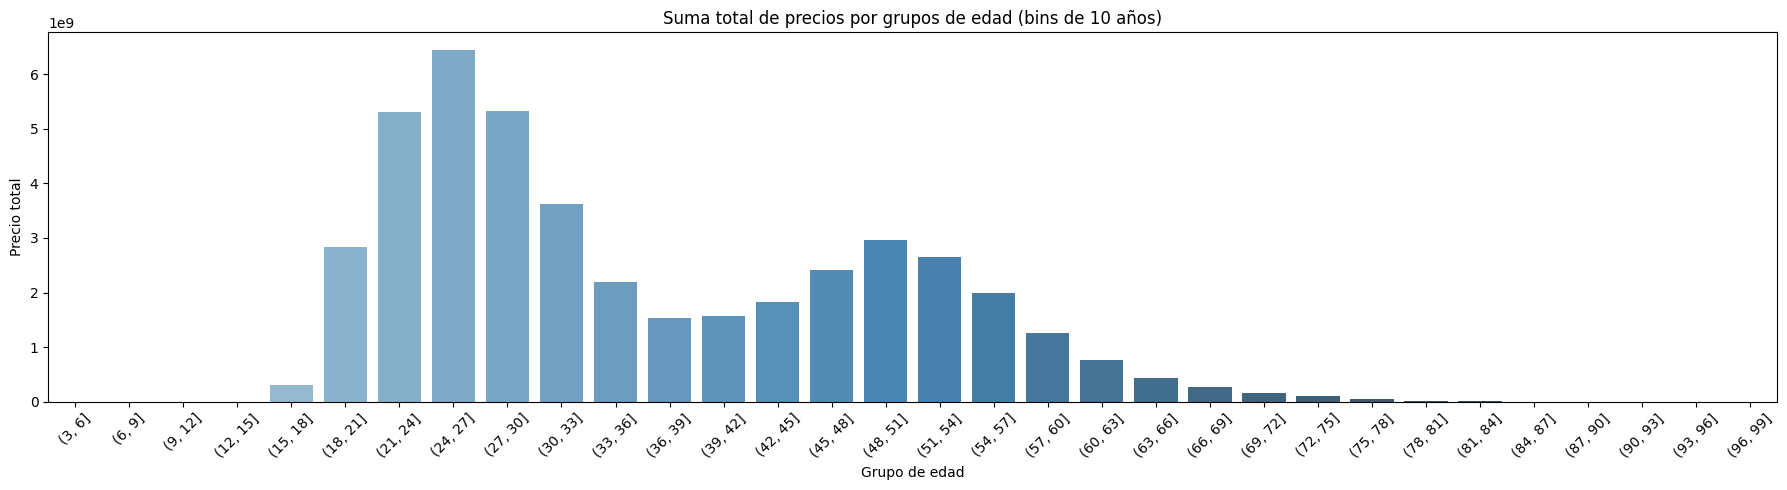

In [142]:
# 1. Crear los bins de 3 en 3
df_price_age = price_age.groupby('age', as_index = False)['price'].sum()
df_price_age['age_group'] = pd.cut(price_age['age'], bins=range(3, 101, 3))

# 2. Agrupar por grupo de edad y sumar precio
df_price_age = df_price_age.groupby('age_group', as_index=False)['price'].sum()

# 3. Graficar
plt.figure(figsize=(18, 5))
sns.barplot(data=df_price_age, x='age_group', y='price', palette='Blues_d')
plt.title('Suma total de precios por grupos de edad (bins de 10 años)')
plt.xlabel('Grupo de edad')
plt.ylabel('Precio total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [143]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_price_age.dropna().copy()
le = LabelEncoder()
df_encoded['age_code'] = le.fit_transform(df_encoded['age_group'])

# Correlación de Pearson
corr = df_encoded[['age_code', 'price']].corr().iloc[0,1]
print(f"Correlación Pearson entre 'fashion' codificada y 'age': {corr*100:.4f}")

Correlación Pearson entre 'fashion' codificada y 'age': -42.1699


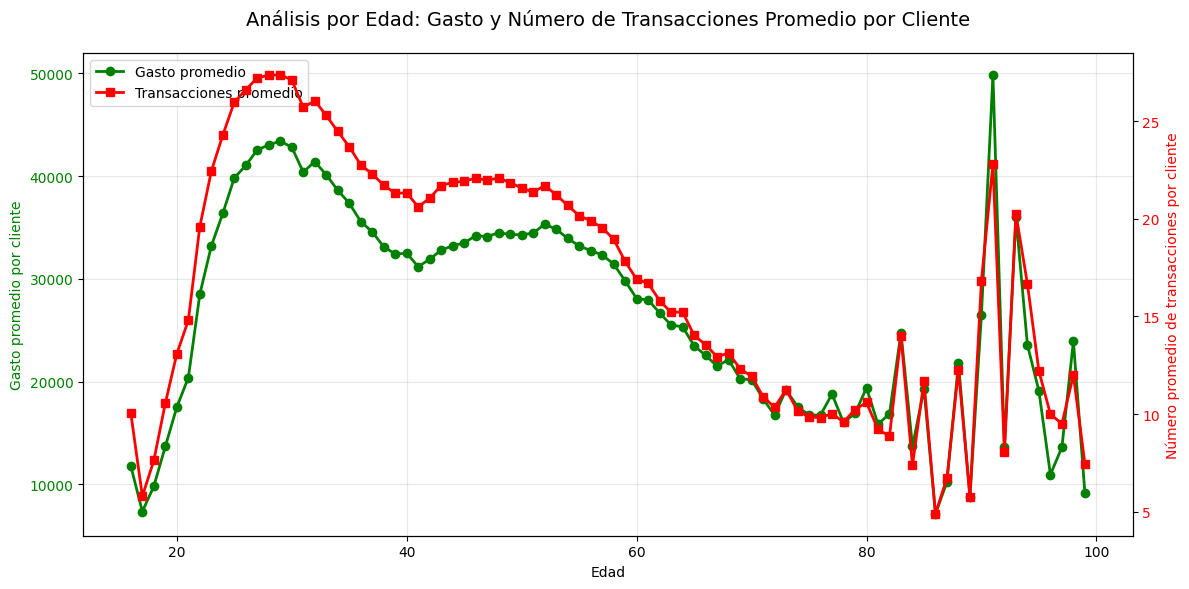

In [144]:
# Primer análisis: Gasto total promedio por cliente
df_summary_gasto = transactions_merged.groupby('age').agg(
    total_spent=('price', 'sum'),
    num_customers=('customer_id', 'nunique')
).reset_index()
df_summary_gasto['avg_spent_per_customer'] = df_summary_gasto['total_spent'] / df_summary_gasto['num_customers']

# Segundo análisis: Número promedio de transacciones por cliente
df_summary_transacciones = transactions_merged.groupby('age').agg(
    total_transactions=('price', 'count'),
    num_customers=('customer_id', 'nunique')
).reset_index()
df_summary_transacciones['avg_transactions_per_customer'] = df_summary_transacciones['total_transactions'] / df_summary_transacciones['num_customers']

# Crear el gráfico combinado con dos ejes Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Línea verde: Gasto promedio por cliente (eje Y izquierdo)
color1 = 'green'
ax1.set_xlabel('Edad')
ax1.set_ylabel('Gasto promedio por cliente', color=color1)
line1 = ax1.plot(df_summary_gasto['age'], df_summary_gasto['avg_spent_per_customer'], 
                 marker='o', color=color1, linewidth=2, label='Gasto promedio')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Crear segundo eje Y para la línea roja
ax2 = ax1.twinx()
color2 = 'red'
ax2.set_ylabel('Número promedio de transacciones por cliente', color=color2)
line2 = ax2.plot(df_summary_transacciones['age'], df_summary_transacciones['avg_transactions_per_customer'], 
                 marker='s', color=color2, linewidth=2, label='Transacciones promedio')
ax2.tick_params(axis='y', labelcolor=color2)

# Título y leyenda
plt.title('Análisis por Edad: Gasto y Número de Transacciones Promedio por Cliente', fontsize=14, pad=20)

# Combinar las leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()